In [24]:
import h5py
import numpy as np
import pandas as pd
import os
import datetime
import time
from make_dashboard import make_dashboard
from belt.evaluate import default_belt_merit
from belt.belt_impact import run_belt, evaluate_belt
import json
from belt.tools import NpEncoder
import matplotlib.pyplot as plt

def convertToDatedFormat(destionation_folder):
    curr_date = datetime.date.today()
    year,month,day = curr_date.strftime('%Y'),curr_date.strftime('%m'),curr_date.strftime('%d')
    destionation_folder_dated = destionation_folder + "/" + year + "/" + month + "/" + day

    if not os.path.exists(destionation_folder_dated):
        os.makedirs(destionation_folder_dated)
    
    return destionation_folder_dated



In [27]:
with h5py.File('./snapshot/2024/12/06/LCLSII-snapshot-2024-12-06T22:16:24-08:00.h5', 'r') as f:
    pv_dic = {}
    for key in f.keys():
        pv_dic[key] = np.array(f[key]).item()

/lscratch/jytang/tmp/ipykernel_4027882/2557004094.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  pv_dic[key] = np.array(f[key]).item()


In [28]:
pv_dic

{'ACCL:L1B:0200:AL:BETA': -28.12650179018849,
 'ACCL:L1B:0200:AL:CACT': -126.99903097106615,
 'ACCL:L1B:0200:AL:CO_AMPL': 102.14233275962657,
 'ACCL:L1B:0200:AL:EACT': 173.25459171079137,
 'ACCL:L1B:0200:AL:NEG_AMPL': 73.40307185799708,
 'ACCL:L1B:0200:AL:NOTA_AMPL': 50.7597342171967,
 'ACCL:L1B:0200:AL:NOTA_PHASE': 8.530355381562941,
 'ACCL:L1B:0200:AL:POS_AMPL': 82.31506190336526,
 'ACCL:L2B:0400:AL:BETA': -23.99909092380173,
 'ACCL:L2B:0400:AL:CACT': -580.0081468903165,
 'ACCL:L2B:0400:AL:EACT': 1302.6666040142593,
 'ACCL:L3B:1600:AL:BETA': 0.0,
 'ACCL:L3B:1600:AL:CACT': -0.008329594125825679,
 'ACCL:L3B:1600:AL:EACT': 2044.1946670909979,
 'BEND:BC1B:200:BACT': 0.8449844706991455,
 'BEND:BC1B:400:BACT': 0.8404079827924067,
 'BEND:BC1B:600:BACT': 0.8404070812911093,
 'BEND:BC1B:800:BACT': 0.8404079192400685,
 'BEND:BC2B:200:BACT': 2.343149002361187,
 'BEND:BC2B:500:BACT': 2.343150540799117,
 'BEND:BC2B:600:BACT': 2.3431587480112044,
 'BEND:BC2B:900:BACT': 2.3431533235206055,
 'PHYS:S

In [29]:
CSV = 'pv_mapping/lclsii_belt.csv'
DF = pd.read_csv(CSV)#.dropna()

PVLIST = list(DF['device_pv_name'].dropna()) 


DF

,Variable,device_pv_name,pv_unit
0,L1B_energy,ACCL:L1B:0200:AL:EACT,MV
1,L1B_amp1,ACCL:L1B:0200:AL:CO_AMPL,MV
2,L1B_amp2,ACCL:L1B:0200:AL:NEG_AMPL,MV
3,L1B_amp3,ACCL:L1B:0200:AL:POS_AMPL,MV
4,L1B_chirp,ACCL:L1B:0200:AL:CACT,MV
5,L1B_phase,ACCL:L1B:0200:AL:BETA,deg
6,HL_amplitude,ACCL:L1B:0200:AL:NOTA_AMPL,MV
7,HL_phase,ACCL:L1B:0200:AL:NOTA_PHASE,deg
8,L2B_energy,ACCL:L2B:0400:AL:EACT,MV
9,L2B_chirp,ACCL:L2B:0400:AL:CACT,MV


In [30]:
df = DF[DF['device_pv_name'].notna()]
assert len(df) > 0, 'Empty dataframe!'
    
pv_names = list(df['device_pv_name'])
df['pv_value'] = [pv_dic[k] for k in pv_names]

In [31]:
df

,Variable,device_pv_name,pv_unit,pv_value
0,L1B_energy,ACCL:L1B:0200:AL:EACT,MV,173.254592
1,L1B_amp1,ACCL:L1B:0200:AL:CO_AMPL,MV,102.142333
2,L1B_amp2,ACCL:L1B:0200:AL:NEG_AMPL,MV,73.403072
3,L1B_amp3,ACCL:L1B:0200:AL:POS_AMPL,MV,82.315062
4,L1B_chirp,ACCL:L1B:0200:AL:CACT,MV,-126.999031
5,L1B_phase,ACCL:L1B:0200:AL:BETA,deg,-28.126502
6,HL_amplitude,ACCL:L1B:0200:AL:NOTA_AMPL,MV,50.759734
7,HL_phase,ACCL:L1B:0200:AL:NOTA_PHASE,deg,8.530355
8,L2B_energy,ACCL:L2B:0400:AL:EACT,MV,1302.666604
9,L2B_chirp,ACCL:L2B:0400:AL:CACT,MV,-580.008147


In [69]:
#settings = {"Impact_particles": "/sdf/data/ad/ard/u/jytang/lume-belt-live/example1/from_Litrack_50pC.h5"}
settings = {"Impact_particles": "/sdf/data/ad/ard/u/jytang/lume-belt-live/impact_particles/final_particles_75pC_12072024.h5", "num_doublings": 7}


HL_phase = df.loc[df["Variable"] == "HL_phase", 'pv_value' ].values[0] - 180
HL_amplitude = df.loc[df["Variable"] == "HL_amplitude", 'pv_value' ].values[0]*1e6
HL_gradient = HL_amplitude/5.5346304
    
L1_energy = df.loc[df["Variable"] == "L1B_energy", 'pv_value' ].values[0]
L1_chirp = df.loc[df["Variable"] == "L1B_chirp", 'pv_value' ].values[0]

L1_phase = df.loc[df["Variable"] == "L1B_phase", 'pv_value' ].values[0]
L1_amplitude = (df.loc[df["Variable"] == "L1B_amp1", 'pv_value' ].values[0] + 
                    df.loc[df["Variable"] == "L1B_amp2", 'pv_value' ].values[0] +
                    df.loc[df["Variable"] == "L1B_amp3", 'pv_value' ].values[0])*1e6
L1_gradient = L1_amplitude/16.603888
                    
    #L1_amplitude = np.abs((L1_energy - HL_energy)/ np.cos(L1_phase/180*np.pi)*1e6/16.603888)
    #L1_amplitude = np.abs((L1_energy - HL_energy)*1e6/16.603888)



L2_energy = df.loc[df["Variable"] == "L2B_energy", 'pv_value' ].values[0]
L2_chirp = df.loc[df["Variable"] == "L2B_chirp", 'pv_value' ].values[0]

L2_phase = df.loc[df["Variable"] == "L2B_phase", 'pv_value' ].values[0]
L2_gradient = np.abs(L2_energy/np.cos(L2_phase/180*np.pi)*1e6/99.623328)
    
    

L3_energy = df.loc[df["Variable"] == "L3B_energy", 'pv_value' ].values[0]
L3_chirp = df.loc[df["Variable"] == "L3B_chirp", 'pv_value' ].values[0]

L3_phase = df.loc[df["Variable"] == "L3B_phase", 'pv_value' ].values[0]
L3_gradient = np.abs(L3_energy/np.cos(L3_phase/180*np.pi)*1e6/166.038878)
    #L3_amplitude = np.abs(L3_energy*1e6/166.038878)
    
    
BC1_energy = df.loc[df["Variable"] == "BC1_energy", 'pv_value' ].values[0]/1e3
BC1_rigidity = (df.loc[df["Variable"] == "BCX11", 'pv_value' ].values[0] + df.loc[df["Variable"] == "BCX12", 'pv_value' ].values[0] +
             df.loc[df["Variable"] == "BCX13", 'pv_value' ].values[0] + df.loc[df["Variable"] == "BCX14", 'pv_value' ].values[0])/4/10
BC1_angle = BC1_rigidity/(3.3356*BC1_energy)

BC2_energy = df.loc[df["Variable"] == "BC2_energy", 'pv_value' ].values[0]/1e3
BC2_rigidity = (df.loc[df["Variable"] == "BCX21", 'pv_value' ].values[0] + df.loc[df["Variable"] == "BCX22", 'pv_value' ].values[0] +
             df.loc[df["Variable"] == "BCX23", 'pv_value' ].values[0] + df.loc[df["Variable"] == "BCX24", 'pv_value' ].values[0])/4/10
BC2_angle = BC2_rigidity/(3.3356*BC2_energy)


BC1_energy_increment =BC1_energy*1e9 - (90e6 + L1_amplitude*np.cos(L1_phase/180*np.pi) +  HL_amplitude*np.cos(HL_phase/180*np.pi))
    #BC1_energy_increment =BC1_energy*1e9 - (90e6 + L1_energy*1e6 )
BC2_energy_increment = BC2_energy*1e9 - (BC1_energy*1e9 + L2_energy*1e6)

settings["BC1:angle"] = BC1_angle
settings["BC2:angle"] = BC2_angle
settings["L1:gradient"] = L1_gradient
settings["L1:phase_deg"] = L1_phase 
settings["L2:gradient"] = L2_gradient
settings["L2:phase_deg"] = L2_phase
settings["L3:gradient"] = L3_gradient
settings["L3:phase_deg"] = L3_phase 
settings["HL:gradient"] = HL_gradient
settings["HL:phase_deg"] = HL_phase 
settings["EBC1:energy_increment"] = BC1_energy_increment
settings["EBC2:energy_increment"] = BC2_energy_increment

In [70]:
settings

{'Impact_particles': '/sdf/data/ad/ard/u/jytang/lume-belt-live/impact_particles/final_particles_75pC_12072024.h5',
 'num_doublings': 7,
 'BC1:angle': np.float64(0.10091778633801679),
 'BC2:angle': np.float64(0.046834318978504395),
 'L1:gradient': np.float64(15530125.626057515),
 'L1:phase_deg': np.float64(-28.12650179018849),
 'L2:gradient': np.float64(14313274.604570622),
 'L2:phase_deg': np.float64(-23.99909092380173),
 'L3:gradient': np.float64(12311542.282832084),
 'L3:phase_deg': np.float64(0.0),
 'HL:gradient': np.float64(9171296.102662375),
 'HL:phase_deg': np.float64(-171.46964461843706),
 'EBC1:energy_increment': np.float64(-17211704.62073639),
 'EBC2:energy_increment': np.float64(-52765624.03602576)}

In [71]:
#settings['L2:phase_deg'] -= 0.8

In [72]:
dat = {}

MODEL = 'LCLSII'
HOST = 's3df'
ARCHIVE_DIR = './scan'

SNAPSHOT_DIR = './scan'
SUMMARY_OUTPUT_DIR = './scan'
PLOT_OUTPUT_DIR = './scan'

CONFIG0 = {"input": "example1/belt.in", "workdir": os.environ.get("SCRATCH")}
PREFIX = f'lume-belt-live-demo-{HOST}-{MODEL}'


DASHBOARD_KWARGS = {'outpath':PLOT_OUTPUT_DIR,            
                    'name' : PREFIX
                   }    

SNAPSHOT = None
SNAPSHOT_DIR_DATED = convertToDatedFormat(SNAPSHOT_DIR)
ARCHIVE_DIR_DATED = convertToDatedFormat(ARCHIVE_DIR)
SUMMARY_OUTPUT_DIR_DATED = convertToDatedFormat(SUMMARY_OUTPUT_DIR)

In [73]:
def my_merit(belt_object, itime):
    # Collect standard output statistics
    merit0 = default_belt_merit(belt_object)
    
    PLOT_OUTPUT_DIR_DATED = convertToDatedFormat(PLOT_OUTPUT_DIR)
    #Overriding at runtime to save in dated folders
    DASHBOARD_KWARGS["outpath"] = PLOT_OUTPUT_DIR_DATED
    
    # Make the dashboard from the evaluated object
    plot_file = make_dashboard(belt_object, itime=itime, **DASHBOARD_KWARGS)
    #print('Dashboard written:', plot_file)
    #logger.info(f'Dashboard written: {plot_file}')
    
    # Make all readable
    os.chmod(plot_file, 0o644)
    
    # Assign extra info
    merit0['plot_file'] = plot_file    
    merit0['isotime'] = itime
    
    # Clear any buffers
    plt.close('all')

    return merit0

In [74]:
 # Record inputs
dat['inputs'] = settings
dat['config'] = CONFIG0
dat['pv_mapping_dataframe'] = df.to_dict()
    
itime = '2024-12-06T22:16:24-08:00'

t0 = time.time()

outputs = evaluate_belt(CONFIG0, settings,
                                       merit_f=lambda x: my_merit(x, itime),
                                       archive_path=ARCHIVE_DIR_DATED,
                                        verbose=True )
    
dat['outputs'] =  outputs   
    #logger.info(f'...finished in {(time()-t0):.1f} s')
fname = fname=f'{SUMMARY_OUTPUT_DIR_DATED}/{PREFIX}-scan-{itime}.json'

json.dump(dat, open(fname, 'w'), cls=NpEncoder)

Reading Impact_particles = /sdf/data/ad/ard/u/jytang/lume-belt-live/impact_particles/final_particles_75pC_12072024.h5
Upsampling the particle number to  1279746
Setting BELT BC1:angle = 0.10091778633801679
Setting BELT BC2:angle = 0.046834318978504395
Setting BELT L1:gradient = 15530125.626057515
Setting BELT L1:phase_deg = -28.12650179018849
Setting BELT L2:gradient = 14313274.604570622
Setting BELT L2:phase_deg = -23.99909092380173
Setting BELT L3:gradient = 12311542.282832084
Setting BELT L3:phase_deg = 0.0
Setting BELT HL:gradient = 9171296.102662375
Setting BELT HL:phase_deg = -171.46964461843706
Setting BELT EBC1:energy_increment = -17211704.62073639
Setting BELT EBC2:energy_increment = -52765624.03602576
Configured to run in: /sdf/scratch/users/j/jytang/tmp_ht19mr5
Running BELT in /sdf/scratch/users/j/jytang/tmp_ht19mr5
/sdf/home/j/jytang/miniconda3/envs/lume-eblt-dev/bin/xbelt
Shifting delta_e_over_e0 and delta_gamma given Ek
 EBLT - Electron Beam Longitudinal Tracking (forward

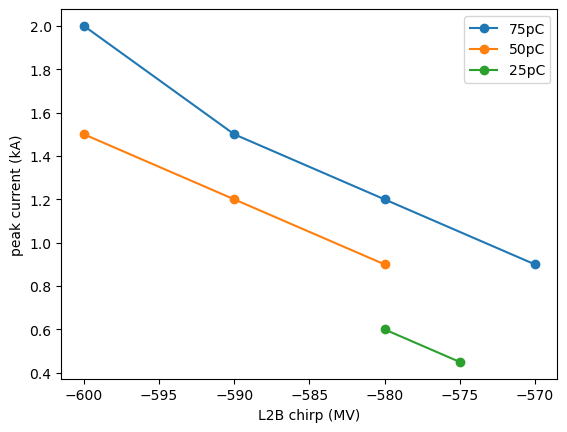

In [5]:
import matplotlib.pyplot as plt
L2_chirp = [-570, -580, -590, -600]
peak_current_1 = [0.9, 1.2, 1.5, 2]

BC1_mag = [0.8454, 0.8404, 0.8344, 0.8324]
peak_current2 = [1.2, 1.5, 2, 2.5]

plt.plot(L2_chirp, peak_current_1, '-o', label = '75pC')

L2_chirp = [-580, -590, -600]
peak_current_2 = [0.9, 1.2, 1.5]

plt.plot(L2_chirp, peak_current_2, '-o',label = '50pC')

L2_chirp = [-575, -580]
peak_current_3 = [0.45, 0.6]

plt.plot(L2_chirp, peak_current_3, '-o',label = '25pC')

plt.xlabel('L2B chirp (MV)')
plt.ylabel('peak current (kA)')

plt.legend()

Text(0, 0.5, 'peak current(kA)')

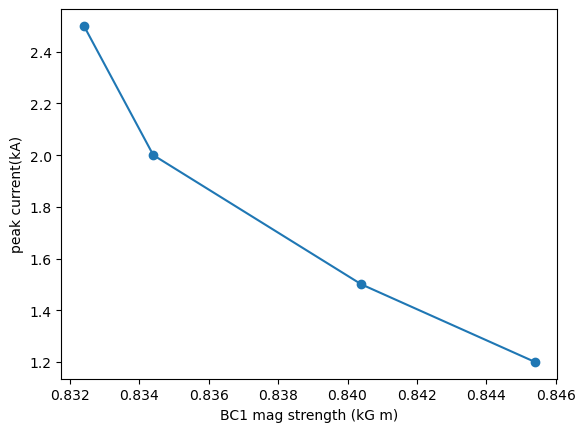

In [8]:
BC1_mag = [0.8454, 0.8404, 0.8344, 0.8324]
peak_current2 = [1.2, 1.5, 2, 2.5]

plt.plot(BC1_mag, peak_current2, '-o')
plt.xlabel('BC1 mag strength (kG m)')
plt.ylabel('peak current(kA)')

In [11]:
from belt.run import BELT

In [32]:
BELT.from_archive('./archive/2024/11/29/0825690ee5df266cf90f4a21d86272a0.h5')

KeyError: "Unable to synchronously open object (object 'input' doesn't exist)"